<a href="https://colab.research.google.com/github/choweyyy/DS-Final-Project/blob/main/Copy_of_Final_Project_DS_58.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.offline as pyo
import seaborn as sns
!pip install streamlit
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
from PIL import Image
import plotly.graph_objs as go
import plotly.io as pio
!pip install pyngrok

In [28]:
url = 'https://drive.google.com/uc?export=download&id=1SOMpQNhr5CPDdj5flrMUdwMEQVYeehaa'
df = pd.read_csv(url)
df

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.00,25000.7500,50000.5000,75000.2500,100000.00
age,100000.0,47.521500,15.988752,0.00,37.0000,48.0000,58.0000,100.00
income,100000.0,49873.905000,46800.214127,1100.00,21100.0000,36200.0000,62200.0000,1061800.00
household_size,100000.0,2.430900,1.075126,1.00,2.0000,2.0000,3.0000,9.00
dependents,100000.0,0.898380,0.950654,0.00,0.0000,1.0000,1.0000,7.00
bmi,100000.0,26.990512,4.994883,12.00,23.6000,27.0000,30.4000,50.40
visits_last_year,100000.0,1.927650,1.737730,0.00,1.0000,2.0000,3.0000,25.00
hospitalizations_last_3yrs,100000.0,0.093640,0.304848,0.00,0.0000,0.0000,0.0000,3.00
days_hospitalized_last_3yrs,100000.0,0.373350,1.373011,0.00,0.0000,0.0000,0.0000,21.00
medication_count,100000.0,1.236320,1.209358,0.00,0.0000,1.0000,2.0000,11.00


In [31]:
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


=== SHAPE ===
(100000, 54)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker            

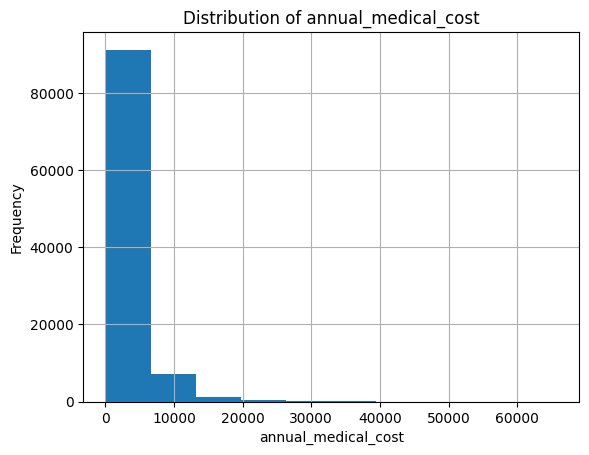

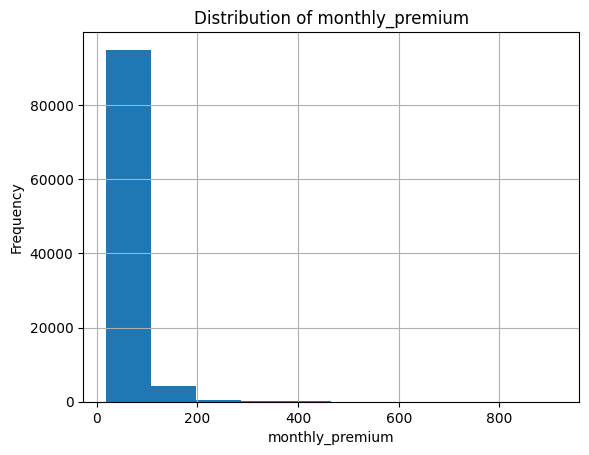

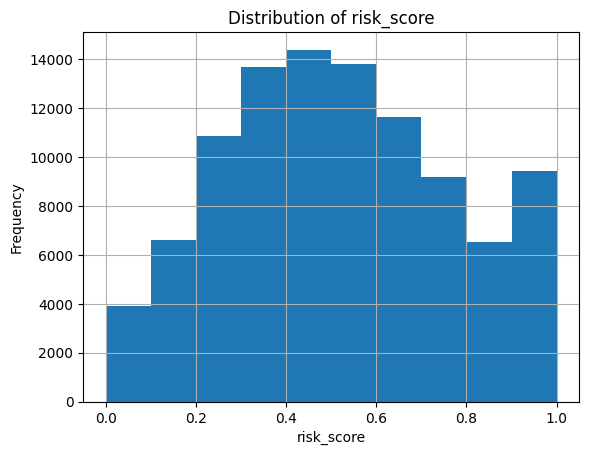

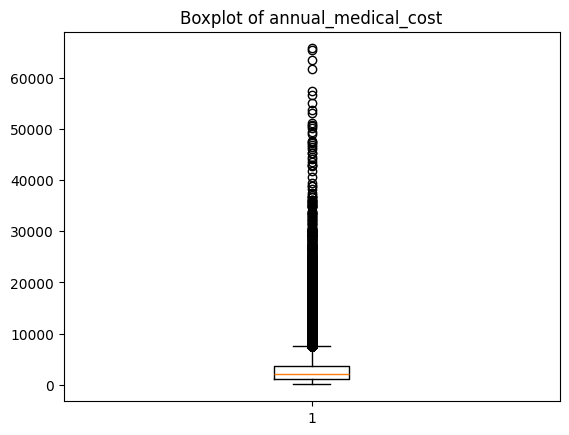

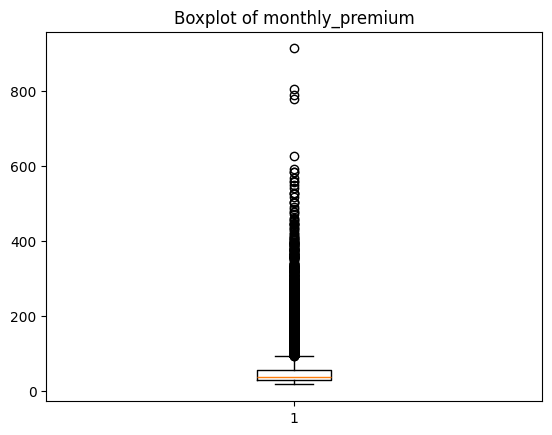

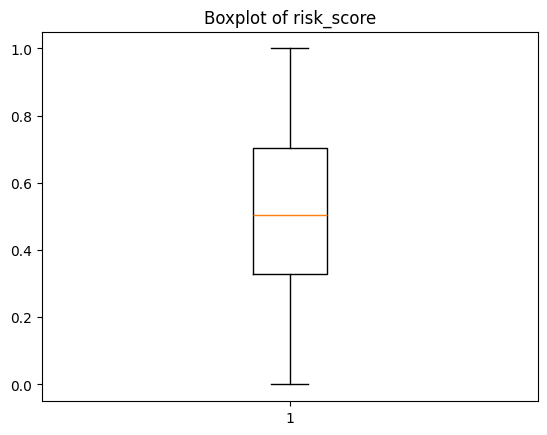


=== VALUE COUNTS: sex ===
sex
Female    49193
Male      48794
Other      2013
Name: count, dtype: int64

=== VALUE COUNTS: region ===
region
South      28029
North      22027
East       19984
West       17879
Central    12081
Name: count, dtype: int64

=== VALUE COUNTS: urban_rural ===
urban_rural
Urban       60019
Suburban    25021
Rural       14960
Name: count, dtype: int64

=== VALUE COUNTS: education ===
education
Bachelors       27996
Some College    25112
HS              24827
Masters         13987
No HS            5120
Doctorate        2958
Name: count, dtype: int64

=== VALUE COUNTS: marital_status ===
marital_status
Married     53252
Single      35715
Divorced     6984
Widowed      4049
Name: count, dtype: int64

=== VALUE COUNTS: employment_status ===
employment_status
Employed         55269
Retired          19864
Unemployed       12939
Self-employed    11928
Name: count, dtype: int64

=== VALUE COUNTS: smoker ===
smoker
Never      69709
Former     18163
Current    12128
Nam

In [32]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== INFO ===")
print(df.info())

print("\n=== HEAD ===")
print(df.head())

# ==============================
# 4. STATISTICAL SUMMARY
# ==============================
print("\n=== DESCRIBE ===")
print(df.describe(include='all'))

# ==============================
# 5. MISSING VALUES
# ==============================
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

print(missing_df)

# ==============================
# 6. DUPLICATE CHECK
# ==============================
print("\n=== DUPLICATES ===")
print(df.duplicated().sum())

# ==============================
# 7. DATA TYPES CHECK
# ==============================
print("\n=== DATA TYPES ===")
print(df.dtypes)

# ==============================
# 8. CORRELATION MATRIX
# ==============================
corr = df.corr(numeric_only=True)

print("\n=== CORRELATION ===")
print(corr["annual_medical_cost"].sort_values(ascending=False))

# ==============================
# 9. DISTRIBUTION PLOTS
# ==============================
numeric_cols = [
    "annual_medical_cost",
    "monthly_premium",
    "risk_score"
]

for col in numeric_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# ==============================
# 10. OUTLIER CHECK (BOXPLOT)
# ==============================
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# ==============================
# 11. CATEGORICAL ANALYSIS
# ==============================
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n=== VALUE COUNTS: {col} ===")
    print(df[col].value_counts())

# ==============================
# 12. GROUP ANALYSIS (IMPORTANT)
# ==============================
# Example: high risk vs low risk
if "is_high_risk" in df.columns:
    print("\n=== COST BY RISK GROUP ===")
    print(df.groupby("is_high_risk")["annual_medical_cost"].mean())

# Example: chronic condition impact
if "chronic_count" in df.columns:
    print("\n=== COST BY CHRONIC COUNT ===")
    print(df.groupby("chronic_count")["annual_medical_cost"].mean())


In [33]:
outliers[[
    "annual_medical_cost",
    "risk_score",
    "chronic_count",
    "hospitalizations_last_3yrs"
]].sort_values(by="annual_medical_cost", ascending=False).head(10)

,annual_medical_cost,risk_score,chronic_count,hospitalizations_last_3yrs
35155,65724.90,0.9890,1,1
20315,65431.24,0.4615,1,2
84802,63482.48,1.0000,3,1
14207,61796.26,1.0000,4,0
27689,57421.29,0.8681,1,0
13758,56596.07,1.0000,4,0
3520,55098.52,0.9451,3,0
81772,53780.11,1.0000,1,0
3616,53168.71,0.9011,2,1
53026,51088.89,0.8681,2,0


In [34]:
df["is_outlier"] = (df["annual_medical_cost"] > upper)

df.groupby("is_outlier")[[
    "annual_medical_cost",
    "risk_score",
    "chronic_count"
]].mean()

,annual_medical_cost,risk_score,chronic_count
is_outlier,,,
False,2379.153667,0.506950,0.683099
True,11686.570090,0.697431,1.297696


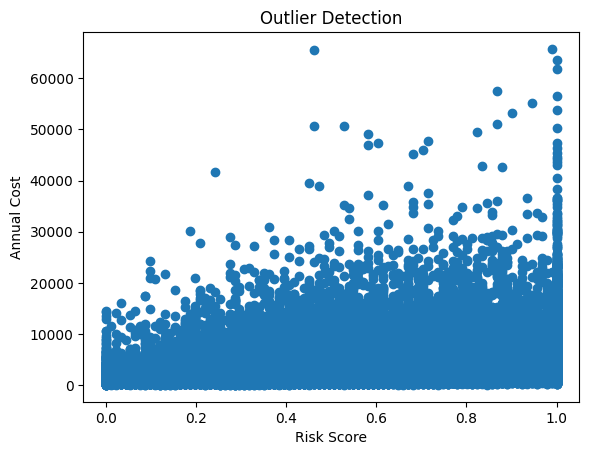

In [35]:
plt.scatter(df["risk_score"], df["annual_medical_cost"])
plt.xlabel("Risk Score")
plt.ylabel("Annual Cost")
plt.title("Outlier Detection")
plt.show()

In [66]:
df["outlier_type"] = "normal"

df.loc[(df["is_outlier"] == True) & (df["chronic_count"] >= 2), "outlier_type"] = "expected"

df.loc[(df["is_outlier"] == True) & (df["chronic_count"] < 2), "outlier_type"] = "unexpected"

In [67]:
df.groupby("outlier_type")[[
    "risk_score",
    "chronic_count",
    "days_hospitalized_last_3yrs"
]].mean()

,risk_score,chronic_count,days_hospitalized_last_3yrs
outlier_type,,,
expected,0.864313,2.295508,1.024035
normal,0.506950,0.683099,0.309800
unexpected,0.597397,0.699575,1.382617


In [68]:
df["outlier_type"].value_counts()

,count
outlier_type,
normal,93228
unexpected,4234
expected,2538


In [69]:
df["outlier_type"].value_counts(normalize=True)

,proportion
outlier_type,
normal,0.93228
unexpected,0.04234
expected,0.02538


In [70]:
df.groupby("outlier_type")["annual_medical_cost"].mean()

,annual_medical_cost
outlier_type,
expected,12413.974968
normal,2379.153667
unexpected,11250.539485


In [71]:
df.groupby("outlier_type")[[
    "visits_last_year",
    "medication_count",
    "proc_surgery_count"
]].mean()

,visits_last_year,medication_count,proc_surgery_count
outlier_type,,,
expected,3.877857,2.168243,0.392829
normal,1.867465,1.211664,0.152508
unexpected,2.083845,1.220595,0.154464


In [72]:
df[df["outlier_type"]=="unexpected"].describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,high_cost,risk_x_chronic,severity_score
count,4234.000000,4234.000000,4234.000000,4234.000000,4234.000000,4234.000000,4234.000000,4234.000000,4234.000000,4234.000000,...,4234.000000,4234.000000,4234.000000,4234.000000,4234.000000,4234.000000,4234.000000,4234.0,4234.000000,4234.000000
mean,50337.677374,51.049362,49013.816722,2.431743,0.903401,27.497780,2.083845,0.288144,1.382617,1.220595,...,0.510156,0.154464,0.499291,0.504251,0.513226,0.493623,0.324516,1.0,0.458737,0.829464
std,28913.846080,15.877906,44645.007535,1.072692,0.953625,4.980179,1.493290,0.495304,2.591403,1.136758,...,0.716328,0.384246,0.697350,0.704081,0.684919,0.500018,0.468249,0.0,0.343687,0.654305
min,50.000000,0.000000,1100.000000,1.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
25%,25403.000000,40.000000,21200.000000,2.000000,0.000000,24.100000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.503840
50%,50398.000000,51.000000,36500.000000,2.000000,1.000000,27.500000,2.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.527500,0.626920
75%,75406.500000,62.000000,61475.000000,3.000000,1.000000,31.000000,3.000000,1.000000,2.000000,2.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.736300,0.849600
max,99989.000000,100.000000,625900.000000,7.000000,6.000000,46.500000,8.000000,3.000000,18.000000,7.000000,...,4.000000,3.000000,4.000000,5.000000,4.000000,1.000000,1.000000,1.0,1.000000,4.719760


<Axes: xlabel='risk_score', ylabel='Density'>

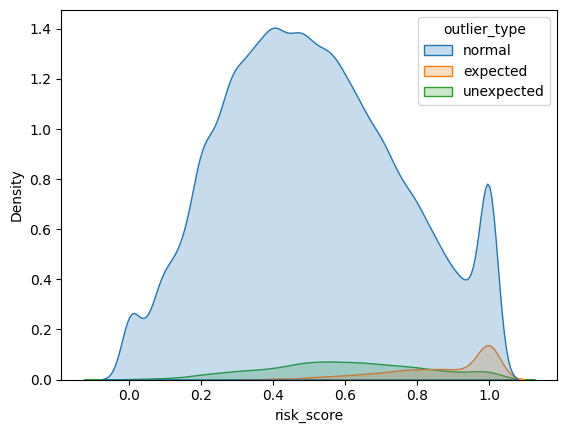

In [73]:
sns.kdeplot(data=df, x="risk_score", hue="outlier_type", fill=True)

In [74]:
df.groupby("outlier_type")[[
    "bmi",
    "income",
    "age"
]].mean()

,bmi,income,age
outlier_type,,,
expected,27.224862,50215.287628,53.666273
normal,26.961094,49903.672716,47.193998
unexpected,27.497780,49013.816722,51.049362


In [75]:
df.groupby(pd.cut(df["risk_score"], bins=5))["high_cost"].mean()

/tmp/ipykernel_13236/2997649933.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,high_cost
risk_score,
"(-0.001, 0.2]",0.025010
"(0.2, 0.4]",0.044978
"(0.4, 0.6]",0.082079
"(0.6, 0.8]",0.128757
"(0.8, 1.0]",0.228136


<Axes: >

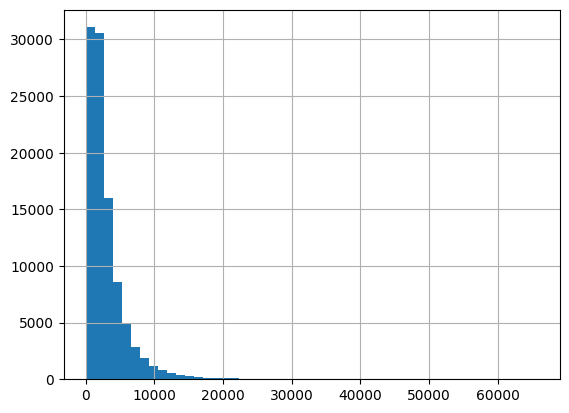

In [47]:
df["annual_medical_cost"].hist(bins=50)

In [48]:
df["cost_group"] = pd.qcut(df["annual_medical_cost"], q=3, labels=["Low", "Mid", "High"])

In [49]:
df.groupby("cost_group")[[
    "risk_score",
    "chronic_count",
    "visits_last_year"
]].mean()

/tmp/ipykernel_13236/2219050491.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,risk_score,chronic_count,visits_last_year
cost_group,,,
Low,0.417516,0.430264,1.523235
Mid,0.517895,0.703717,1.886599
High,0.624133,1.040169,2.373103


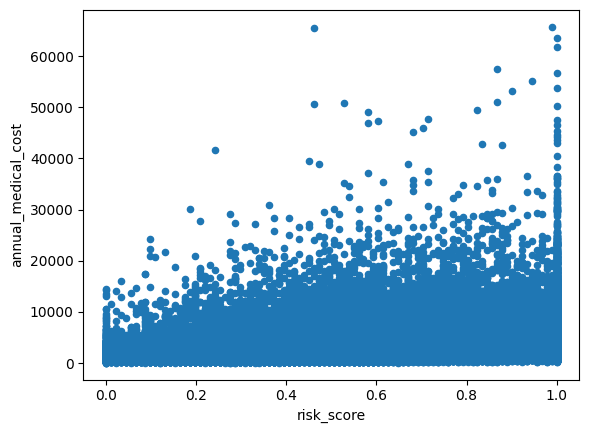

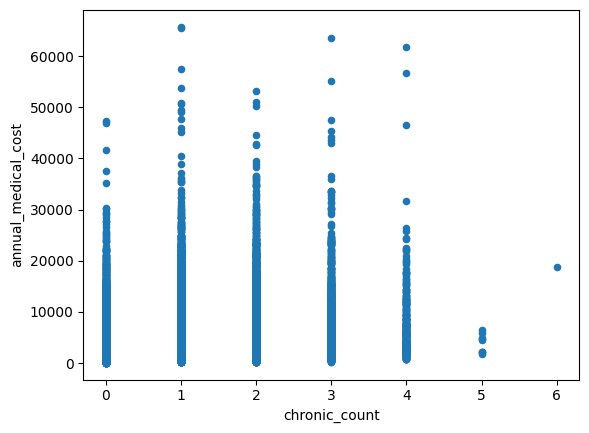

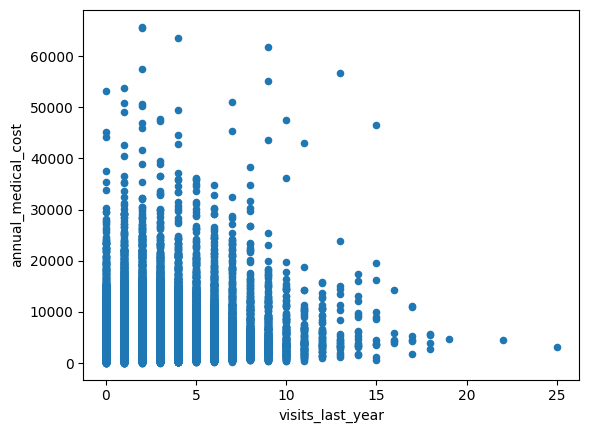

In [50]:
cols = ["risk_score", "chronic_count", "visits_last_year"]

for col in cols:
    df.plot.scatter(x=col, y="annual_medical_cost")

In [77]:
disease_cols = [
    "hypertension",
    "diabetes",
    "asthma",
    "copd",
    "cardiovascular_disease",
    "cancer_history",
    "kidney_disease",
    "liver_disease",
    "arthritis",
    "mental_health"
]

for col in disease_cols:
    print(f"\n{col}")
    print(df.groupby(col)["annual_medical_cost"].mean())


hypertension
hypertension
0    2765.556574
1    3964.353982
Name: annual_medical_cost, dtype: float64

diabetes
diabetes
0    2906.492493
1    4104.670247
Name: annual_medical_cost, dtype: float64

asthma
asthma
0    2946.227522
1    4020.193632
Name: annual_medical_cost, dtype: float64

copd
copd
0    2967.271997
1    4140.565739
Name: annual_medical_cost, dtype: float64

cardiovascular_disease
cardiovascular_disease
0    2952.428070
1    4066.827848
Name: annual_medical_cost, dtype: float64

cancer_history
cancer_history
0    2983.861747
1    4173.548419
Name: annual_medical_cost, dtype: float64

kidney_disease
kidney_disease
0    2993.528690
1    4082.668003
Name: annual_medical_cost, dtype: float64

liver_disease
liver_disease
0    2990.014304
1    4306.033460
Name: annual_medical_cost, dtype: float64

arthritis
arthritis
0    2883.695569
1    4044.773379
Name: annual_medical_cost, dtype: float64

mental_health
mental_health
0    2856.751875
1    4030.103899
Name: annual_medical_c

In [78]:
for col in disease_cols:
    print(f"\n{col}")
    print(df.groupby(col)["high_cost"].mean())


hypertension
hypertension
0    0.082945
1    0.166773
Name: high_cost, dtype: float64

diabetes
diabetes
0    0.093100
1    0.173397
Name: high_cost, dtype: float64

asthma
asthma
0    0.095747
1    0.167997
Name: high_cost, dtype: float64

copd
copd
0    0.097070
1    0.178581
Name: high_cost, dtype: float64

cardiovascular_disease
cardiovascular_disease
0    0.095823
1    0.177448
Name: high_cost, dtype: float64

cancer_history
cancer_history
0    0.098121
1    0.185495
Name: high_cost, dtype: float64

kidney_disease
kidney_disease
0    0.098683
1    0.188782
Name: high_cost, dtype: float64

liver_disease
liver_disease
0    0.098728
1    0.184834
Name: high_cost, dtype: float64

arthritis
arthritis
0    0.091097
1    0.173299
Name: high_cost, dtype: float64

mental_health
mental_health
0    0.089624
1    0.169356
Name: high_cost, dtype: float64


In [79]:
for col in disease_cols:
    print(f"\n{col}")
    print(pd.crosstab(df[col], df["outlier_type"], normalize="index"))


hypertension
outlier_type  expected    normal  unexpected
hypertension                                
0             0.013471  0.944925    0.041604
1             0.072008  0.882772    0.045220

diabetes
outlier_type  expected    normal  unexpected
diabetes                                    
0             0.020075  0.937281    0.042644
1             0.081811  0.879088    0.039102

asthma
outlier_type  expected    normal  unexpected
asthma                                      
0             0.021740  0.935450    0.042810
1             0.083574  0.881604    0.034822

copd
outlier_type  expected    normal  unexpected
copd                                        
0             0.023215  0.934225    0.042560
1             0.083449  0.880111    0.036439

cardiovascular_disease
outlier_type            expected    normal  unexpected
cardiovascular_disease                                
0                       0.022027  0.935289    0.042684
1                       0.087551  0.876490    0.03595

In [82]:
df["disease_count"] = df[disease_cols].sum(axis=1)

In [83]:
df.groupby("disease_count")["high_cost"].mean()

,high_cost
disease_count,
0,0.043884
1,0.118444
2,0.202654
3,0.292414
4,0.414557
5,0.111111
6,1.000000


In [84]:
df.groupby([
    pd.cut(df["risk_score"], bins=5),
    pd.cut(df["disease_count"], bins=4)
])["high_cost"].mean()

/tmp/ipykernel_13236/270033724.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



risk_score     disease_count
(-0.001, 0.2]  (-0.006, 1.5]    0.025010
               (1.5, 3.0]            NaN
               (3.0, 4.5]            NaN
               (4.5, 6.0]            NaN
(0.2, 0.4]     (-0.006, 1.5]    0.044377
               (1.5, 3.0]       0.108225
               (3.0, 4.5]            NaN
               (4.5, 6.0]            NaN
(0.4, 0.6]     (-0.006, 1.5]    0.077552
               (1.5, 3.0]       0.155204
               (3.0, 4.5]            NaN
               (4.5, 6.0]            NaN
(0.6, 0.8]     (-0.006, 1.5]    0.113723
               (1.5, 3.0]       0.183437
               (3.0, 4.5]            NaN
               (4.5, 6.0]            NaN
(0.8, 1.0]     (-0.006, 1.5]    0.192284
               (1.5, 3.0]       0.246820
               (3.0, 4.5]       0.414557
               (4.5, 6.0]       0.200000
Name: high_cost, dtype: float64

/tmp/ipykernel_13236/2831482303.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



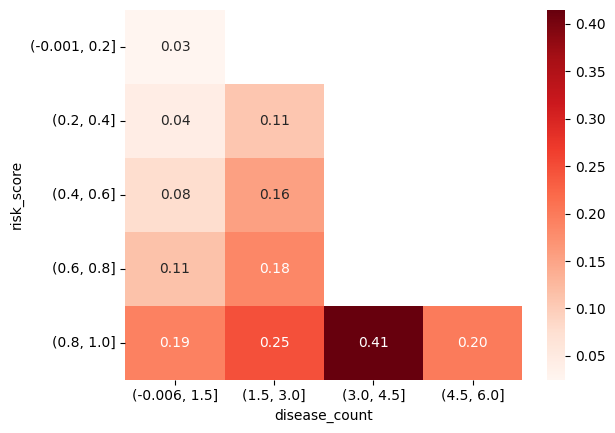

In [86]:
pivot = df.groupby([
    pd.cut(df["risk_score"], bins=5),
    pd.cut(df["disease_count"], bins=4)
])["high_cost"].mean().unstack()
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds")
plt.show()

In [37]:
categorical_cols = df.select_dtypes(include=["object"]).columns
print(categorical_cols)


Index(['sex', 'region', 'urban_rural', 'education', 'marital_status',
       'employment_status', 'smoker', 'alcohol_freq', 'plan_type',
       'network_tier', 'cost_segment'],
      dtype='object')


In [38]:
df_encoded = pd.get_dummies(df, columns=[
    "sex", "region", "urban_rural",
    "marital_status", "employment_status",
    "smoker", "plan_type", "network_tier"
], drop_first=True)

In [39]:
education_map = {
    "No HS": 0,
    "HS": 1,
    "Some College": 2,
    "Bachelors": 3,
    "Masters": 4,
    "Doctorate": 5
}

df_encoded["education"] = df["education"].map(education_map)

In [40]:
df_encoded["alcohol_freq"] = df["alcohol_freq"].fillna("Unknown")

In [41]:
alcohol_map = {
    "Unknown": 0,
    "Occasional": 1,
    "Weekly": 2,
    'Daily': 3
}

df_encoded["alcohol_freq"] = df["alcohol_freq"].map(alcohol_map)

In [42]:
df.groupby("chronic_count")["annual_medical_cost"].mean()

,annual_medical_cost
chronic_count,
0,2176.331749
1,3332.012914
2,4438.189257
3,5671.426627
4,7320.433196
5,3885.147778
6,18747.810000


In [43]:
df.groupby("is_high_risk")["annual_medical_cost"].mean()

,annual_medical_cost
is_high_risk,
0,2408.490469
1,4042.381440


In [44]:
df_encoded

,person_id,age,income,education,household_size,dependents,bmi,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,...,employment_status_Self-employed,employment_status_Unemployed,smoker_Former,smoker_Never,plan_type_HMO,plan_type_POS,plan_type_PPO,network_tier_Gold,network_tier_Platinum,network_tier_Silver
0,75722,52,22700.0,5,3,1,27.4,NaN,2,0,...,False,False,False,True,False,False,True,False,False,False
1,80185,79,12800.0,0,3,1,26.6,2.0,2,0,...,False,False,False,True,False,True,False,True,False,False
2,19865,68,40700.0,1,5,3,31.5,NaN,1,0,...,False,False,False,True,True,False,False,False,True,False
3,76700,15,15600.0,2,5,3,31.6,NaN,0,0,...,True,False,False,True,True,False,False,False,False,True
4,92992,53,89600.0,5,2,0,30.5,3.0,3,0,...,True,False,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,127200.0,0,2,0,28.2,1.0,0,0,...,False,False,False,True,False,False,True,False,False,False
99996,54887,42,21600.0,1,2,0,27.6,1.0,0,0,...,False,False,False,True,False,False,True,False,False,True
99997,76821,41,81900.0,1,1,0,29.8,2.0,7,0,...,False,True,True,False,False,False,True,True,False,False
99998,861,51,43400.0,5,3,2,21.9,1.0,4,0,...,False,True,False,True,False,True,False,False,False,False


In [45]:
df_encoded.isna().sum()

,0
person_id,0
age,0
income,0
education,0
household_size,0
...,...
plan_type_POS,0
plan_type_PPO,0
network_tier_Gold,0
network_tier_Platinum,0


In [46]:
df_encoded.corr(numeric_only=True)["annual_medical_cost"].sort_values(ascending=False).head(10)

,annual_medical_cost
annual_medical_cost,1.000000
monthly_premium,0.965416
annual_premium,0.965415
is_outlier,0.747775
total_claims_paid,0.739402
avg_claim_amount,0.632996
risk_score,0.305971
chronic_count,0.296720
is_high_risk,0.251923
days_hospitalized_last_3yrs,0.230246
